<a href="https://colab.research.google.com/github/MarioPEL58/Finance/blob/main/frontiera_efficiente_da_yf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# See which indexes are available here: https://github.com/paolocole/Stock-Indexes-Historical-Data/tree/main/DAILY/NET

tickers_list=  ["0P0000M2UJ.F","0P0000TM60",
                "0P0000ZNSK.F","0P00016TO5.F",
                "0P00019MC0.F","0P0001CJHB.F",
                "0P0001CJHE.F","0P0001E2AQ.F",
                "0P0001FLNU.F","0P0001HV3A",
                "0P0001HV4N.F","0P0001K4MH.F",
                "0P0001PBIM.F","0P0001PL98.F",
                "0P0001PPS5.F","0P0001PQG4.F",
                "0P0001PQG5.F","0P0001R92D.F",
                "0P0001RC7E.F","0P0001RCEO.F",
                "0P0001TAAN.F","0P0001X0QU.F"]


In [15]:
import pandas as pd
import yfinance as yf

def load_data(tickers):
    """
    Scarica i dati storici da Yahoo Finance per una lista di ticker.
    Recupera gli ultimi 10 anni di dati.
    """
    # Scarichiamo i dati per un periodo di 10 anni
    df = yf.download(tickers, period='10y', progress=False, auto_adjust=True)

    # Gestione MultiIndex (quando ci sono più ticker)
    if isinstance(df.columns, pd.MultiIndex):
        if 'Close' in df.columns.levels[0]:
            df = df['Close']
    else:
        # Gestione Ticker singolo
        if 'Close' in df.columns:
            df = df[['Close']]

    return df.sort_index()

# Esecuzione usando la tickers_list definita nella cella precedente
merged_df = load_data(tickers_list)

# Visualizzazione
print(f"Periodo caricato: dal {merged_df.index.min().date()} al {merged_df.index.max().date()}")
print(f"Asset caricati: {len(merged_df.columns)}")
display(merged_df.head())

Periodo caricato: dal 2022-03-04 al 2026-06-22
Asset caricati: 22


Ticker,0P0000M2UJ.F,0P0000TM60,0P0000ZNSK.F,0P00016TO5.F,0P00019MC0.F,0P0001CJHB.F,0P0001CJHE.F,0P0001E2AQ.F,0P0001FLNU.F,0P0001HV3A,...,0P0001PBIM.F,0P0001PL98.F,0P0001PPS5.F,0P0001PQG4.F,0P0001PQG5.F,0P0001R92D.F,0P0001RC7E.F,0P0001RCEO.F,0P0001TAAN.F,0P0001X0QU.F
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-04,NaN,NaN,NaN,1497.150024,NaN,NaN,NaN,NaN,NaN,5.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-07,148.389999,226.809998,141.360001,1468.560059,1717.150024,4.682,6.733,5.859,138.789993,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-08,148.830002,227.880005,138.410004,NaN,1715.140015,4.721,6.725,5.849,138.410004,4.788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-09,150.639999,226.369995,138.449997,1468.270020,1749.890015,5.004,6.791,5.803,141.289993,4.798,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-10,150.759995,226.029999,144.190002,1466.349976,1745.390015,4.880,6.808,5.835,140.660004,4.771,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Find rows where all columns are present (no NaNs)
mask = merged_df.notna().all(axis=1)

if mask.any():
    # Get the index of the first and last row that has no NaNs
    first_valid = mask.idxmax()
    last_valid = mask[::-1].idxmax()

    # Slice the dataframe from the first fully valid row to the last fully valid row
    merged_df = merged_df.loc[first_valid:last_valid]

print(f"New shape: {merged_df.shape}")
display(merged_df.head())
display(merged_df.tail())

New shape: (228, 22)


Ticker,0P0000M2UJ.F,0P0000TM60,0P0000ZNSK.F,0P00016TO5.F,0P00019MC0.F,0P0001CJHB.F,0P0001CJHE.F,0P0001E2AQ.F,0P0001FLNU.F,0P0001HV3A,...,0P0001PBIM.F,0P0001PL98.F,0P0001PPS5.F,0P0001PQG4.F,0P0001PQG5.F,0P0001R92D.F,0P0001RC7E.F,0P0001RCEO.F,0P0001TAAN.F,0P0001X0QU.F
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-22,172.179993,227.009995,228.929993,1709.030029,2017.640015,6.738,9.519,7.100,181.619995,4.739,...,5.384,3.384,5.781,6.248,5.137,107.744232,5.400,5.383,5.234,5.010
2025-07-23,173.940002,229.839996,234.690002,1721.209961,2028.180054,6.846,9.604,7.117,183.470001,4.810,...,NaN,3.392,5.835,6.273,5.134,108.073929,5.400,5.371,5.238,5.008
2025-07-24,173.729996,229.919998,238.130005,1721.410034,2028.890015,6.897,9.612,7.096,184.169998,4.825,...,NaN,3.403,5.808,6.252,5.112,107.909081,5.381,5.354,5.228,4.992
2025-07-25,173.169998,NaN,236.199997,1726.040039,2041.780029,6.871,9.650,7.118,184.669998,4.774,...,NaN,3.387,5.821,6.291,5.108,107.870293,5.375,5.350,5.231,4.989
2025-07-28,172.470001,229.520004,235.020004,1732.689941,2058.110107,6.854,9.655,7.139,185.050003,4.792,...,NaN,3.433,5.825,6.353,5.119,108.015747,5.386,5.358,5.224,4.998


Ticker,0P0000M2UJ.F,0P0000TM60,0P0000ZNSK.F,0P00016TO5.F,0P00019MC0.F,0P0001CJHB.F,0P0001CJHE.F,0P0001E2AQ.F,0P0001FLNU.F,0P0001HV3A,...,0P0001PBIM.F,0P0001PL98.F,0P0001PPS5.F,0P0001PQG4.F,0P0001PQG5.F,0P0001R92D.F,0P0001RC7E.F,0P0001RCEO.F,0P0001TAAN.F,0P0001X0QU.F
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-10,194.820007,224.889999,313.359985,1873.420044,2361.149902,8.053,11.936,7.784,207.410004,4.613,...,NaN,4.564,6.503,6.864,5.103,109.089996,5.305,5.267,5.265,4.986
2026-06-11,194.690002,225.210007,313.059998,1902.339966,2421.169922,8.054,12.111,7.830,209.970001,4.588,...,NaN,4.581,6.587,7.001,5.118,109.169998,5.314,5.283,5.279,4.992
2026-06-12,197.350006,NaN,316.690002,1914.329956,2422.939941,8.216,12.267,7.844,212.110001,4.675,...,NaN,4.619,6.631,6.999,5.131,109.250000,5.329,5.288,5.275,5.000
2026-06-15,198.960007,230.479996,325.429993,1940.319946,2491.689941,8.255,12.387,7.810,214.860001,4.782,...,NaN,4.811,6.644,7.112,5.148,109.389999,5.344,5.297,5.280,5.007
2026-06-16,198.860001,232.289993,324.649994,1933.310059,2453.179932,8.310,12.412,7.840,214.210007,4.730,...,5.483,4.816,6.597,7.074,5.154,109.389999,5.352,5.307,5.283,5.008


In [17]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 228 entries, 2025-07-22 to 2026-06-16
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   0P0000M2UJ.F  221 non-null    float64
 1   0P0000TM60    172 non-null    float64
 2   0P0000ZNSK.F  209 non-null    float64
 3   0P00016TO5.F  212 non-null    float64
 4   0P00019MC0.F  215 non-null    float64
 5   0P0001CJHB.F  224 non-null    float64
 6   0P0001CJHE.F  224 non-null    float64
 7   0P0001E2AQ.F  224 non-null    float64
 8   0P0001FLNU.F  215 non-null    float64
 9   0P0001HV3A    205 non-null    float64
 10  0P0001HV4N.F  224 non-null    float64
 11  0P0001K4MH.F  214 non-null    float64
 12  0P0001PBIM.F  48 non-null     float64
 13  0P0001PL98.F  208 non-null    float64
 14  0P0001PPS5.F  217 non-null    float64
 15  0P0001PQG4.F  217 non-null    float64
 16  0P0001PQG5.F  220 non-null    float64
 17  0P0001R92D.F  213 non-null    float64
 18  0P0001RC7E.

/tmp/ipykernel_5176/3752465696.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = merged_df.pct_change()


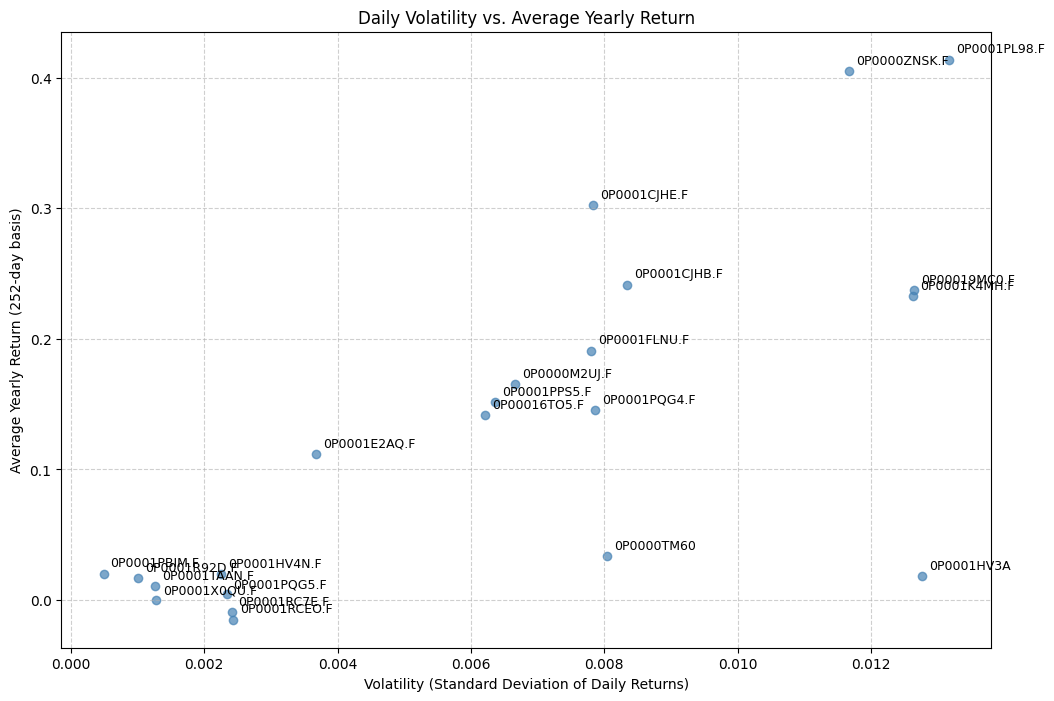

,Yearly Return,Daily Volatility
Ticker,,
0P0000M2UJ.F,0.165550,0.006666
0P0000TM60,0.033634,0.008041
0P0000ZNSK.F,0.405191,0.011672
0P00016TO5.F,0.141764,0.006207
0P00019MC0.F,0.237155,0.012640
0P0001CJHB.F,0.241600,0.008338
0P0001CJHE.F,0.302470,0.007830
0P0001E2AQ.F,0.111777,0.003671
0P0001FLNU.F,0.190926,0.007805


In [19]:
import matplotlib.pyplot as plt

# Calculate daily percentage returns
returns_df = merged_df.pct_change()

# Calculate mean return and volatility (std dev)
# We annualize the return by multiplying by 252 (trading days)
stats = pd.DataFrame({
    'Yearly Return': returns_df.mean() * 252,
    'Daily Volatility': returns_df.std()
})

# Create the scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(stats['Daily Volatility'], stats['Yearly Return'], alpha=0.7, color='steelblue')

# Add labels for each point
for i, txt in enumerate(stats.index):
    plt.annotate(txt, (stats['Daily Volatility'].iloc[i], stats['Yearly Return'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Daily Volatility vs. Average Yearly Return')
plt.xlabel('Volatility (Standard Deviation of Daily Returns)')
plt.ylabel('Average Yearly Return (252-day basis)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(stats)

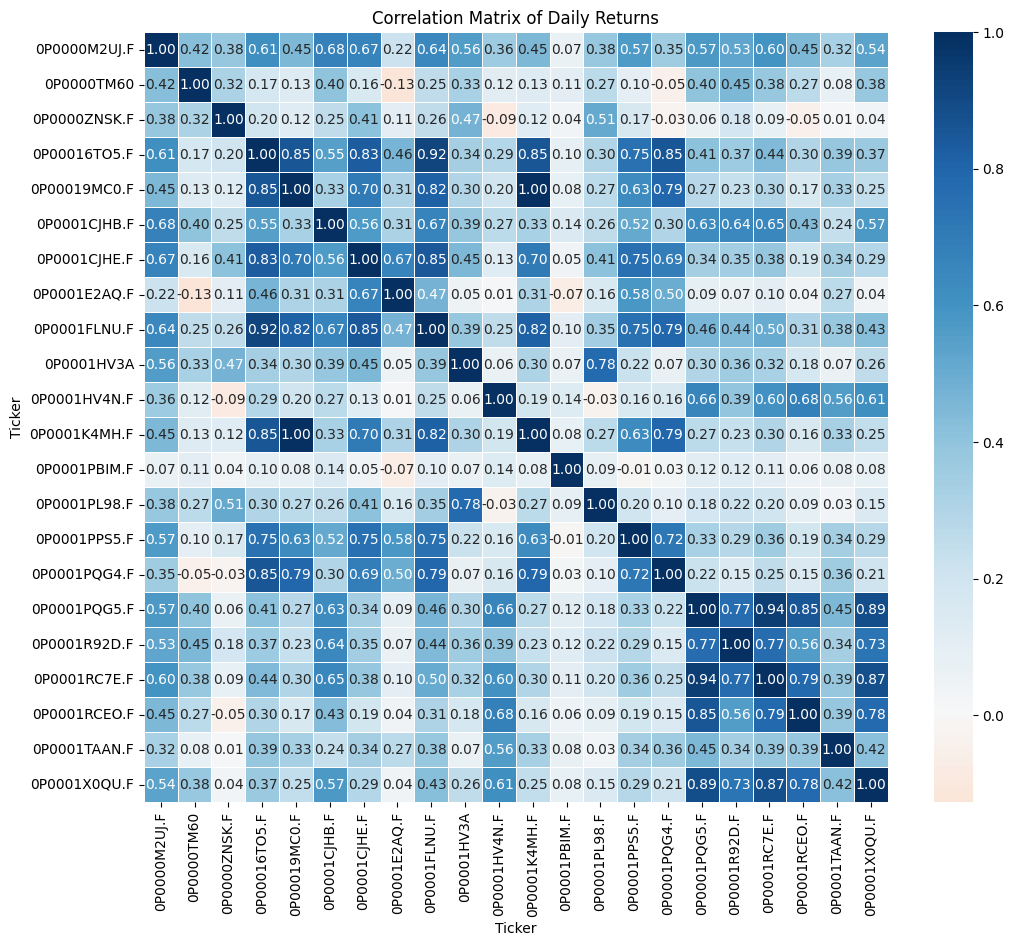

In [20]:
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = returns_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Daily Returns')
plt.show()

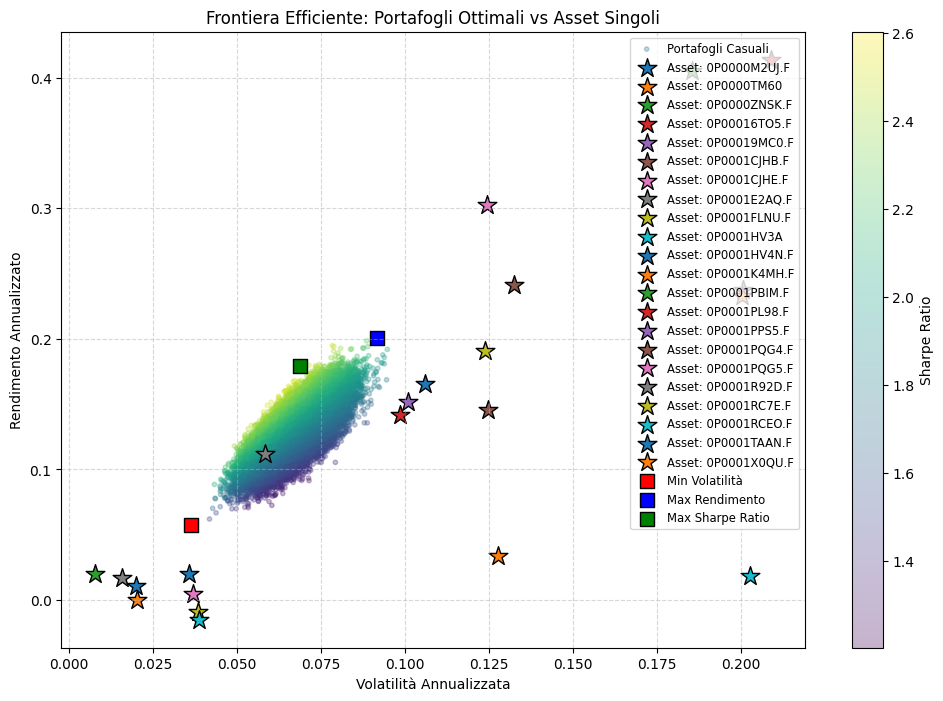

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Asset selezionati
#assets = ['USA', 'GERMANY', 'ITALY', 'EUROPE', 'UNITED-KINGDOM','JAPAN','SWITZERLAND','SPAIN','EM-EMERGING-MARKETS']

assets = ['USA','SWITZERLAND','EM-EMERGING-MARKETS','MEXICO']
assets = tickers_list
# assets=['USA','JAPAN','SWITZERLAND','SPAIN','EM-EMERGING-MARKETS']
subset_returns = returns_df[assets].dropna()

# Parametri annualizzati
mean_returns = subset_returns.mean() * 252
cov_matrix = subset_returns.cov() * 252

num_portfolios = 50000
results = np.zeros((3, num_portfolios))
weights_record = []

# Simulazione Monte Carlo
np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = results[0,i] / results[1,i]

# Identificazione portafogli ottimali
min_vol_idx = np.argmin(results[1,:])
max_ret_idx = np.argmax(results[0,:])
max_sharpe_idx = np.argmax(results[2,:])

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3, label='Portafogli Casuali')
plt.colorbar(label='Sharpe Ratio')

for asset in assets:
    vol = subset_returns[asset].std() * np.sqrt(252)
    ret = mean_returns[asset]
    plt.scatter(vol, ret, marker='*', s=200, edgecolors='black', label=f'Asset: {asset}')

plt.scatter(results[1, min_vol_idx], results[0, min_vol_idx], color='red', marker='s', s=100, edgecolors='black', label='Min Volatilità')
plt.scatter(results[1, max_ret_idx], results[0, max_ret_idx], color='blue', marker='s', s=100, edgecolors='black', label='Max Rendimento')
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], color='green', marker='s', s=100, edgecolors='black', label='Max Sharpe Ratio')

plt.title('Frontiera Efficiente: Portafogli Ottimali vs Asset Singoli')
plt.xlabel('Volatilità Annualizzata')
plt.ylabel('Rendimento Annualizzato')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [24]:
import pandas as pd

summary_stats = pd.DataFrame({
    'Asset': assets,
    'Min Volatilità': [f"{weights_record[min_vol_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Max Rendimento': [f"{weights_record[max_ret_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Max Sharpe Ratio': [f"{weights_record[max_sharpe_idx][i]*100:.2f}%" for i in range(len(assets))]
})

metrics = pd.DataFrame([
    ['---', '---', '---', '---'],
    ['Rendimento Ann.', f"{results[0, min_vol_idx]:.2%}", f"{results[0, max_ret_idx]:.2%}", f"{results[0, max_sharpe_idx]:.2%}"],
    ['Volatilità Ann.', f"{results[1, min_vol_idx]:.2%}", f"{results[1, max_ret_idx]:.2%}", f"{results[1, max_sharpe_idx]:.2%}"],
    ['Sharpe Ratio', f"{results[2, min_vol_idx]:.2f}", f"{results[2, max_ret_idx]:.2f}", f"{results[2, max_sharpe_idx]:.2f}"]
], columns=['Asset', 'Min Volatilità', 'Max Rendimento', 'Max Sharpe Ratio'])

final_summary = pd.concat([summary_stats, metrics], ignore_index=True)
print("Dettagli dei Portafogli Ottimali:")
display(final_summary)

Dettagli dei Portafogli Ottimali:


,Asset,Min Volatilità,Max Rendimento,Max Sharpe Ratio
0,0P0000M2UJ.F,2.69%,1.09%,3.64%
1,0P0000TM60,3.04%,1.68%,3.79%
2,0P0000ZNSK.F,1.12%,10.15%,10.15%
3,0P00016TO5.F,0.12%,4.83%,6.32%
4,0P00019MC0.F,0.21%,10.34%,6.08%
5,0P0001CJHB.F,3.14%,9.23%,3.41%
6,0P0001CJHE.F,3.15%,9.46%,9.01%
7,0P0001E2AQ.F,8.41%,3.24%,11.01%
8,0P0001FLNU.F,0.68%,3.06%,0.08%
9,0P0001HV3A,1.16%,6.32%,0.20%


In [ ]:
url = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/DAILY/NET/"

elenco = {  "WORLD":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
            "WORLD SMALL CAPS":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/SMALL-CAP/WORLD-SMALL-CAP.csv",
            "GOLD":"EUR/EXTRA/GOLD.csv"
}

In [ ]:
file_bonds = "https://www.paolocoletti.com/wp-content/uploads/youtube/tassi_btp_eurobond.xlsx"
# ESTER is in sheet "ESTER", 11th column Date, 12th column ESTER price (not rate), first row contains headers
# GOV BONDS is in sheet "Eurozone", 1st column Date, 6th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# short GOV BONDS is in sheet "Eurozone", 1st column Date, 2nd column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# long GOV BONDS is in sheet "Eurozone", 1st column Date, 5th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# EURIBOR are in sheet "Euribor", column 1 is date with header, columns 2-3-4-5 are euribor 1M 3M 6M 12M, these are prices and not rates.